# US Visa Prediction Project

## Life cycle of Machine learning Project

- Understanding the problem statement
- Data Collection
- Exploratory Data Analysis
- Data Cleaning 
- Data Pre- Processing
- Model Traing 
- Choose best model

### About 
#### The Immigration and Nationality Act(INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programas are administerd by the office of Foreign Labor Cerification (OFLC)

### 1)Problem Statement.

- OFLC gives job certification application for employers seeking to bring foreign workers into the United States and grants
certifications.
- As in the las year the count of employees were huge so OFLC needs Machine learning modes to shortlist vis application based on their previous data.
In this project we are going to use the data given to build a classification model:
- This model is to check if Visa get approved or not bsed on the given dataset.
- This can be used to Recommend a suitableprofile for the applicatnts for whom the visa should be cerified or denied on the certain criteria which influences the decision.

### 2) Data Collection .
- The Dataset is part of office of Foreign Labor Certification(OFLC)
- The data consists of 25480 Rows and 12 columns

https://www.kaggle.com/datasets/moro23/easyvisa-dataset

### Import Data and Required Package 
Importing Pandas , Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline 

In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

Import the CSV Data as pandas DataFrame

In [4]:
df = pd.read_csv('Visadataset.csv')

Show top 5 Records

In [5]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Shape of the datasets

In [6]:
df.shape

(25480, 12)

Summary of the dataset

In [7]:
# Display summary statistics for a dataframe
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


Check Datatype in the dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [9]:
df.select_dtypes(exclude='number').columns.tolist()

df.select_dtypes(include='number').columns.tolist()

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

### Exploring Data 

In [10]:
# Define numerical and categorical columns

numeric_features = [ feature for feature in df.columns if df[feature].dtype != 'O']

categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']


print('We have {} numerical features : {}'.format(len(numeric_features),numeric_features))

print('\nWe have {} categorical features : {}'.format(len(categorical_features),categorical_features))

We have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

We have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [11]:
numeric_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [12]:
# proportion of count data on categorical columns

for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------------------------------')

    '''Methods to Calculate ProportionsSingle Column Proportion: Use df['column_name'].value_counts(normalize=True) to return relative frequencies instead of raw counts.Percentage Conversion: Multiply the normalized result by 100 (df['column_name'].value_counts(normalize=True) * 100).Iterate Through Multiple Columns: Loop through a list of categorical features to print proportions for each:pythonfor col in categorical_features:
    print(df[col].value_counts(normalize=True))'''

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------------------------------
requires_job_training
N    88.402669
Y    11.597331


### Insights 
- `case_id` have unique values for each column which can be dropped as it, it of no importance.
- `continent` column is highly biased towards Asia, hence we can combine other categories to form a single category.
- `unit_of_wage` seems to an important column as most of them are yearly contracts.

## Univariate Analysis

- The term univariate analysis refers to the analysis of one variable prefix "uni" means 'one'. The purpose of univariate analysis is to understand the distribution of values for a single variable.

## Other type of Analysis are 
- Bivariate Analysis : The analysis of two variables.
- Multivariate Analysis : The analysis of two or more variable

Numerical Analysis :

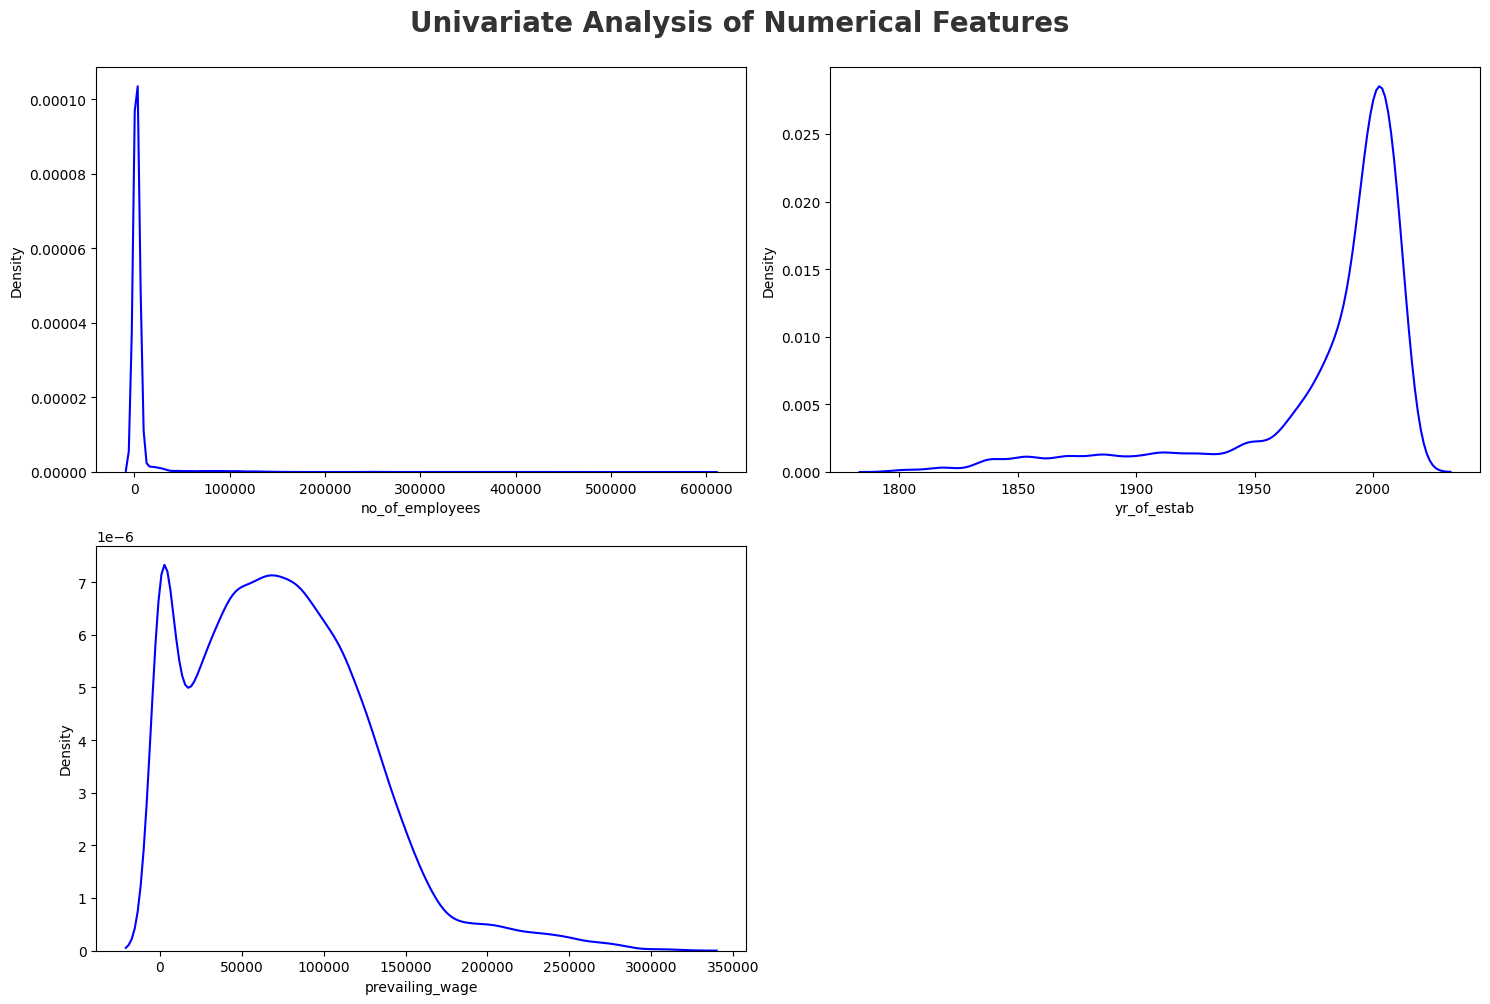

In [13]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features ', fontsize= 20, fontweight = 'bold', alpha=0.8, y=1)

for i in range(0, len(numeric_features)):#numeric_features
    plt.subplot(2,2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

# Save plot
    #plt.savefig('./images/univariate_Num.png')


### Insights 
- `no_of_employees `column looks more skewed but it may be because of outliers.
- `yr_of_estab` is a discrete feature
- `prevailing_wage `is a right_skewed distribution

### Categorical Features

In [14]:
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [15]:
# categorical Columns
categorical_features.remove('case_id')

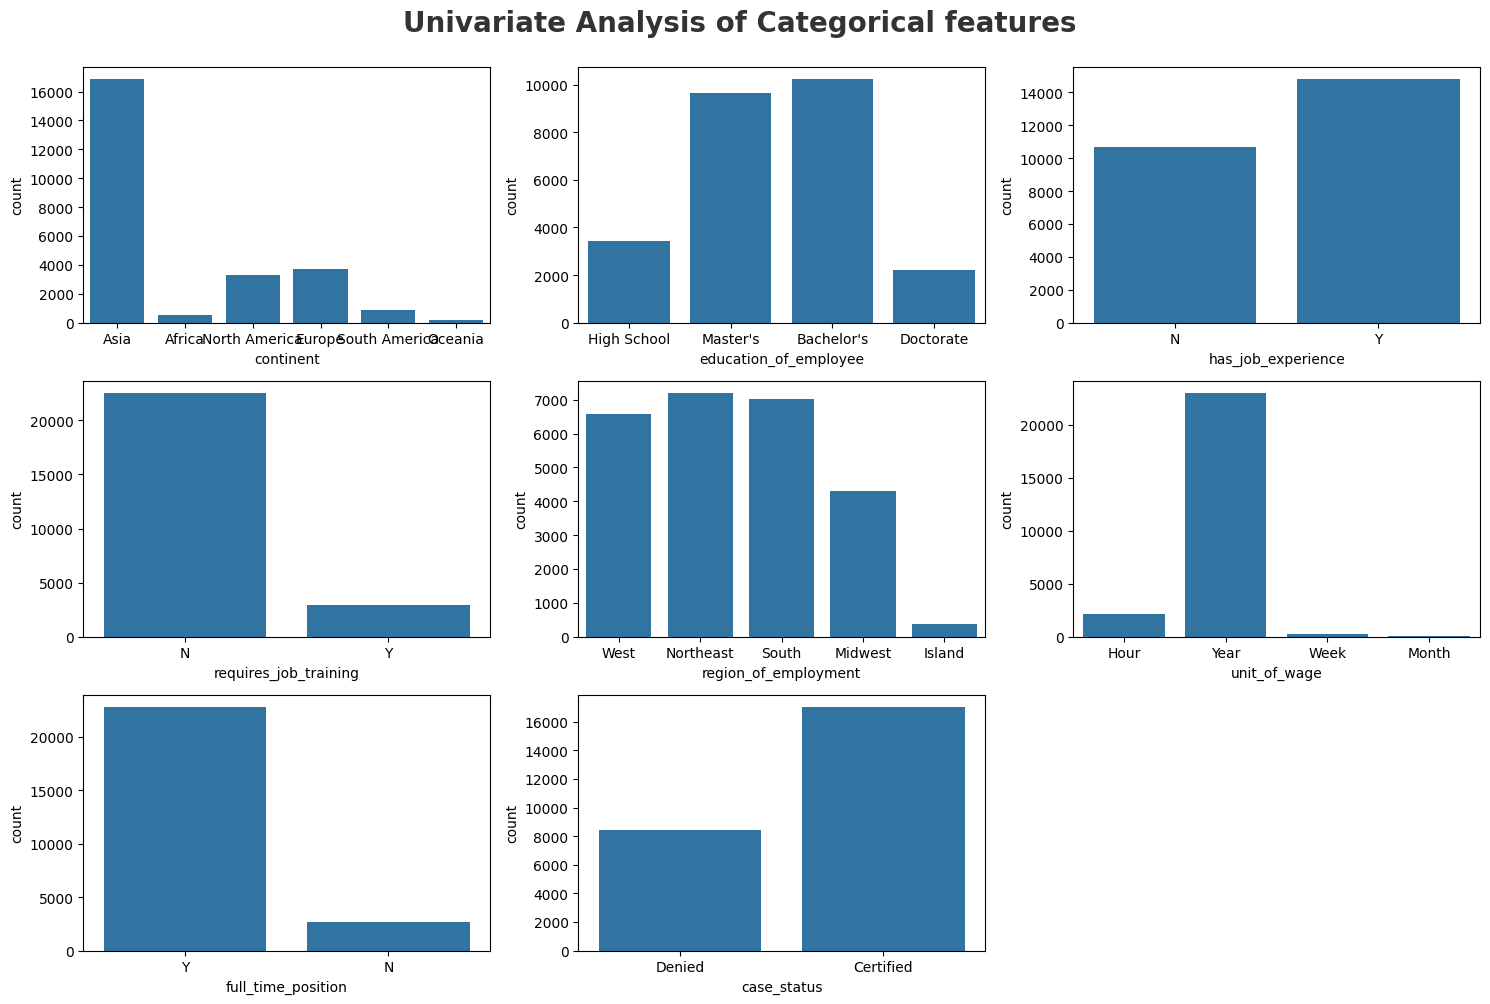

In [16]:
plt.figure(figsize=(15,10))
plt.suptitle('Univariate Analysis of Categorical features ', fontsize = 20, fontweight= 'bold', alpha=0.8, y=1)

for i in range(len(categorical_features)):
    plt.subplot(3,3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

    #save plot
    #plt.savefig('./images/Univariate_cat.png')


### Insights
- `requires_job_training`,`unit_of_wage`,`full_position`, and `continents` coulmns have signle category dominating.
- In rest of the columns are balancedd.

### Multivariate Analysis 
- Multivariate analysis of more than one variable.


In [17]:
discrete_features = [feature for feature in numeric_features if len(df[feature].unique()) <= 25]

continuous_features = [feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features),discrete_features))

print('We have {} continuous features : {}'.format(len(continuous_features), continuous_features))

We have 0 discrete features : []
We have 3 continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


### Check Multicollinearity in Numerical features 

In [18]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### Insights 
- There is no multicollinearity between any variables 


### Check Multicollinearity for categorical features 
- A chi-squared test (also chi-Square or X2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi_squared distributed under the null hypothesis , specifically pearsons chi squared test.
- A chi-square statistic is one way to show a relationship between two categorical variables.
- Here we test correlation of categorical columns with target columns i.e case_status

Null Hypothesis ( 𝐻0 ): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis ( 𝐻1 ): The Feature and Target column are not independent (Correalted)

In [19]:
# Numeric data only
df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [20]:
from scipy.stats import chi2_contingency

chi2_test = []

for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] <0.05:
        chi2_test.append('Reject Null Hypthesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')

result =pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result ']

result
# only categorical datas

,Column,Hypothesis Result
0,continent,Reject Null Hypthesis
1,education_of_employee,Reject Null Hypthesis
2,has_job_experience,Reject Null Hypthesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypthesis
5,unit_of_wage,Reject Null Hypthesis
6,full_time_position,Reject Null Hypthesis
7,case_status,Reject Null Hypthesis


### Report 
- here `requires_job_training` fails to Rejects Null Hypothesis which means it doesn't correlate with target column.

### Checking Null values

In [21]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [22]:
continues_features = [feature for feature in numeric_features if len(df[feature].unique()) >= 10]

print('Number of continues features : ', continues_features)

Number of continues features :  ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


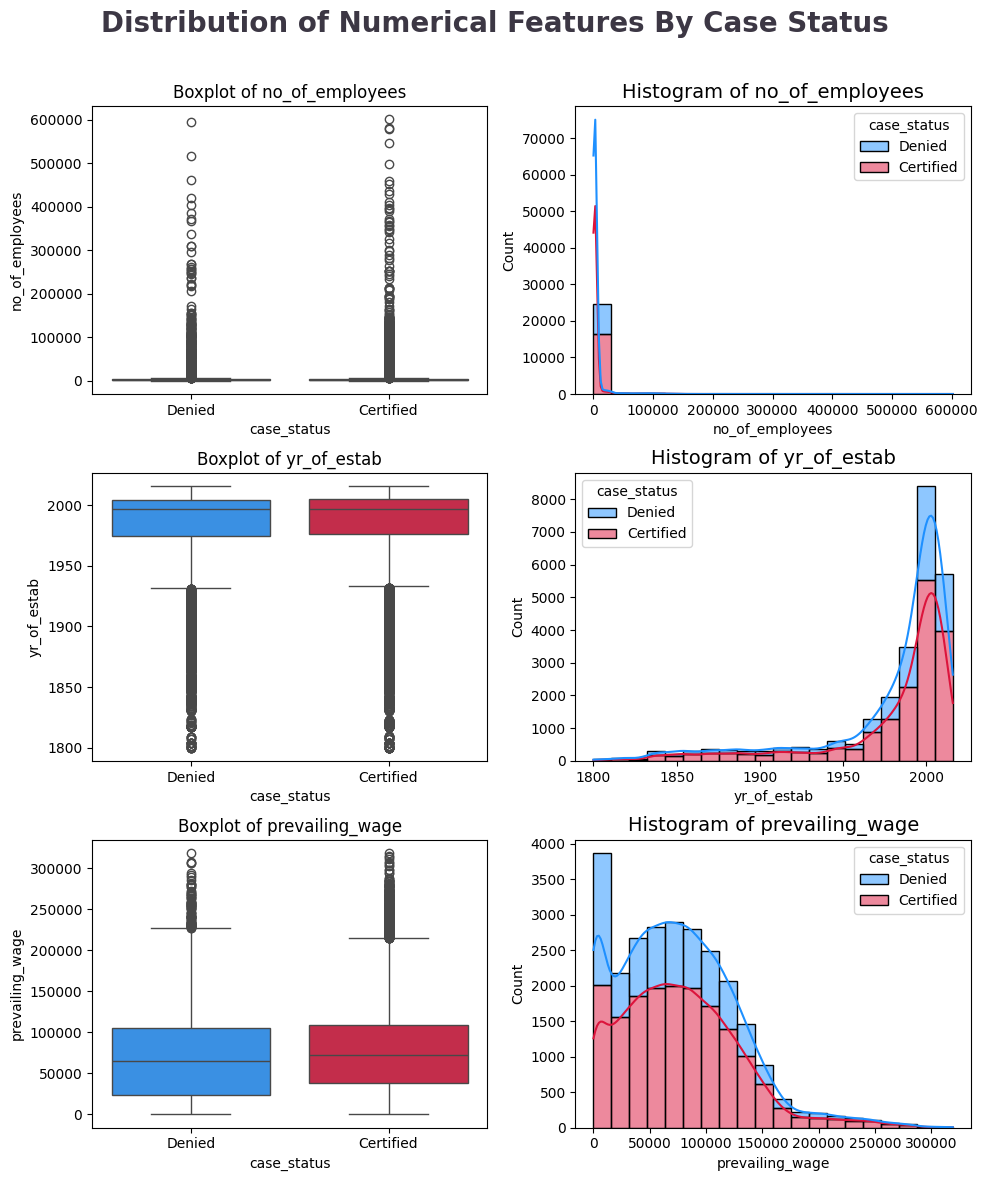

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom color palette using hex codes (Dodger Blue & Crimson Red)
clr1 = ['#1E90FF', '#DC143C']

# Create a 3x2 grid of subplots (3 rows, 2 columns) with total size 10x12 inches
fig, ax = plt.subplots(3, 2, figsize=(10, 12))

# Add a large, bold main title centered above all subplots
fig.suptitle(
    'Distribution of Numerical Features By Case Status',
    color='#3C3744',
    fontsize=20,
    fontweight='bold',
    ha='center'
)

# Loop over numerical feature column names, keeping track of index (i) and column name (col)
for i, col in enumerate(continues_features):
    
    # -------------------------------------------------------------
    # LEFT COLUMN (ax[i, 0]): Box Plot for Outliers & Summary Stats
    # -------------------------------------------------------------
    sns.boxplot(
        data=df, 
        x='case_status', 
        y=col, 
        palette=clr1, 
        ax=ax[i, 0]
    )
    # Set subplot title for the boxplot
    ax[i, 0].set_title(f'Boxplot of {col}', fontsize=12)

    # -------------------------------------------------------------
    # RIGHT COLUMN (ax[i, 1]): Stacked Histogram + KDE Distribution

    sns.histplot(
        data=df, 
        x=col, 
        hue='case_status', 
        bins=20, 
        kde=True,           # Add smooth density curve
        multiple='stack',   # Stack bars for each status on top of each other
        palette=clr1, 
        ax=ax[i, 1]
    )
    # Set subplot title for the histogram
    ax[i, 1].set_title(f'Histogram of {col}', fontsize=14)

# Automatically adjust padding so labels and titles don't overlap
fig.tight_layout()

# Reserve 10% space at top of canvas so suptitle doesn't collide with subplots
fig.subplots_adjust(top=0.90)

# Optional: Uncomment line below to save the plot as a PNG image
# plt.savefig('images/multivariate_num.png')

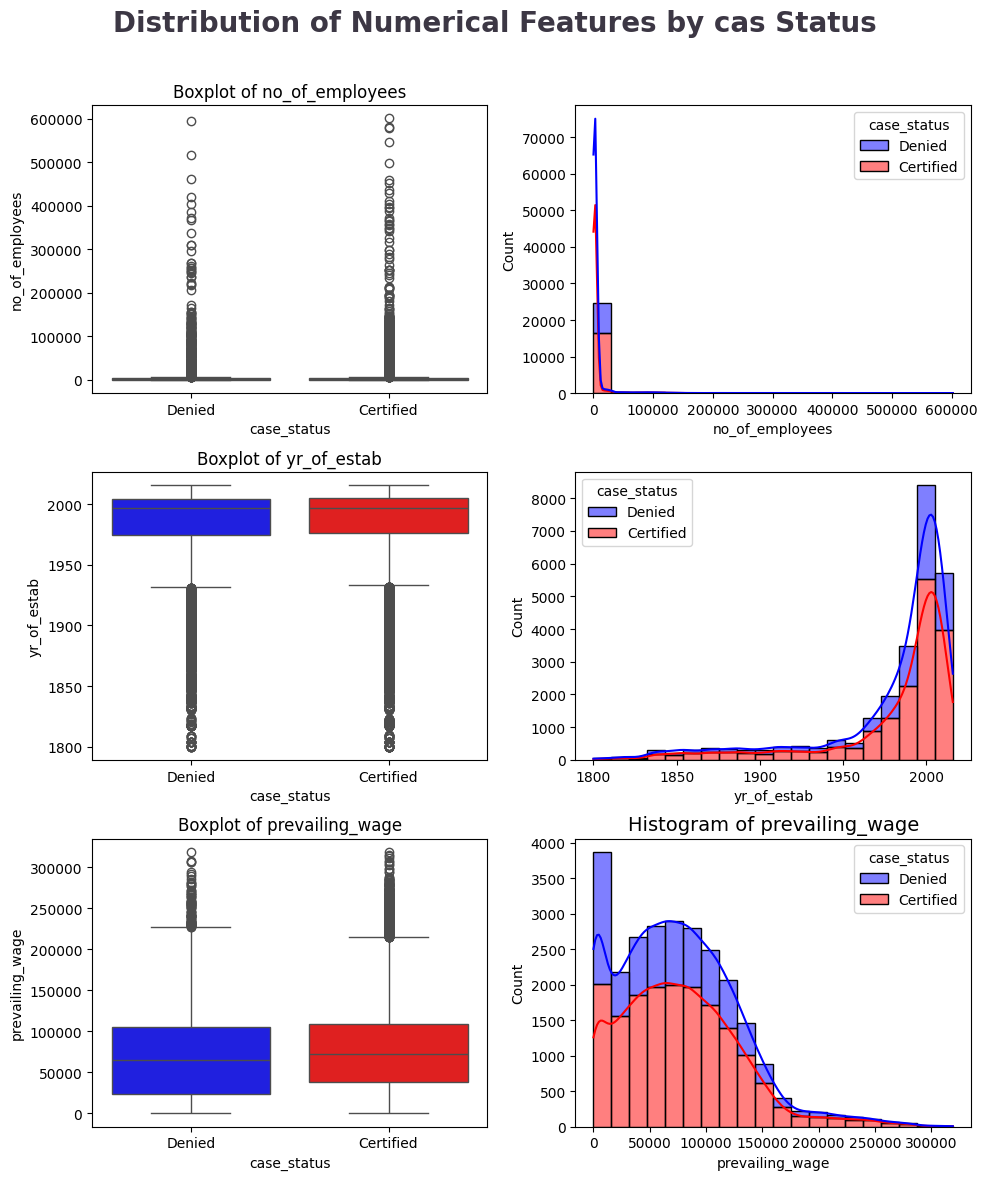

In [24]:
# Define custom color palette using hex codes (Doger blue, crimson red)
clr1 = ['blue','red']

# crate a 3x2 frid of subplots (3 rows ,2 coloumns ) with total size 10x12 inches
fig, ax = plt.subplots(3,2 ,figsize =(10,12))

fig.suptitle("Distribution of Numerical Features by cas Status", color= '#3c3744',
             fontsize =20, fontweight= 'bold', ha= 'center')

# Loop over numerical feature column names, keeeping track of index (i) and colou
for i, col in enumerate(continues_features):
    # -------------------------------------------------------------
    # LEFT COLUMN (ax[i, 0]): Box Plot for Outliers & Summary Stats
    # -------------------------------------------------------------
    sns.boxplot(
        data=df,
        x='case_status',
        y=col,
        palette= clr1,
        ax=ax[i, 0]
    )
    ax[i, 0].set_title(f'Boxplot of {col}', fontsize =12)
# -------------------------------------------------------------
    # RIGHT COLUMN (ax[i, 1]): Stacked Histogram + KDE Distribution
    # -------------------------------------------------------------
    sns.histplot(
    data=df,
    x=col,
    hue='case_status',
    bins=20,
    kde=True,   # add smooth density curve
    multiple='stack', # stack bars for each status on top of each other
    palette=clr1,
    ax=ax[i,1]
)
ax[i, 1].set_title(f'Histogram of {col}', fontsize=14)

# Automatically adjust padding so labels and titles don't overlap
fig.tight_layout()

# Revese 10% space at top of canva sosuptitle dosen't colliede with subplots
fig.subplots_adjust(top=0.90)

# Optional: Uncomment line below to save the plot as a PNG image
# plt.savefig('images/multivariate_num.png')





## Initial Analysis Report

* **No of Employees has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.**
* **`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.**
* **`prevailing_wage` is right skewed with outliers above upper bound of box plot.**
* **There are No missing values in the dataset.**
* **The `case_id` column can be deleted because each row has unique values.**
* **The `case_status` column is the target to predict.**
* **In the Categorical column, features can be made Binary numerical in feature Encoding**

In [25]:
## Visualization

In [26]:
# Visulize the Target Feature

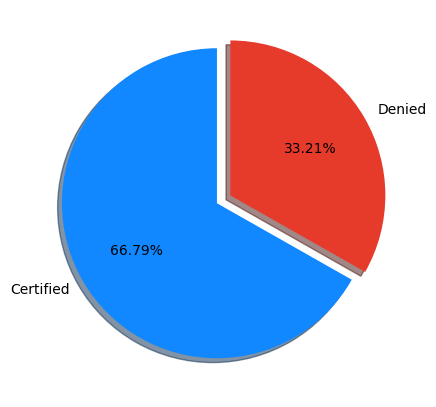

In [27]:
percentage = df.case_status.value_counts(normalize=True)*100

labels = ['Certified','Denied']

# Plot Pie Chart with ploty library
fig, ax = plt.subplots(figsize =(5,8))
explode =(0,0.1)
colors = ['#1188ff','#e63a2a']

ax.pie(percentage, labels= labels, startangle = 90, autopct= '%1.2f%%', explode = explode, shadow= True, colors = colors)
plt.show()

- From the chart it is seen that the Target Variable is Imbalance What is imbalanced data?
Imbalanced data are types of data where the Target class has an uneven distributeion of ovservations, i.e Here Denied value has more count than the Certified value of the Dataset.

### Does applicant Continent has any impact on Visa status?


In [28]:
# group data by continent and their cont of case_status
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

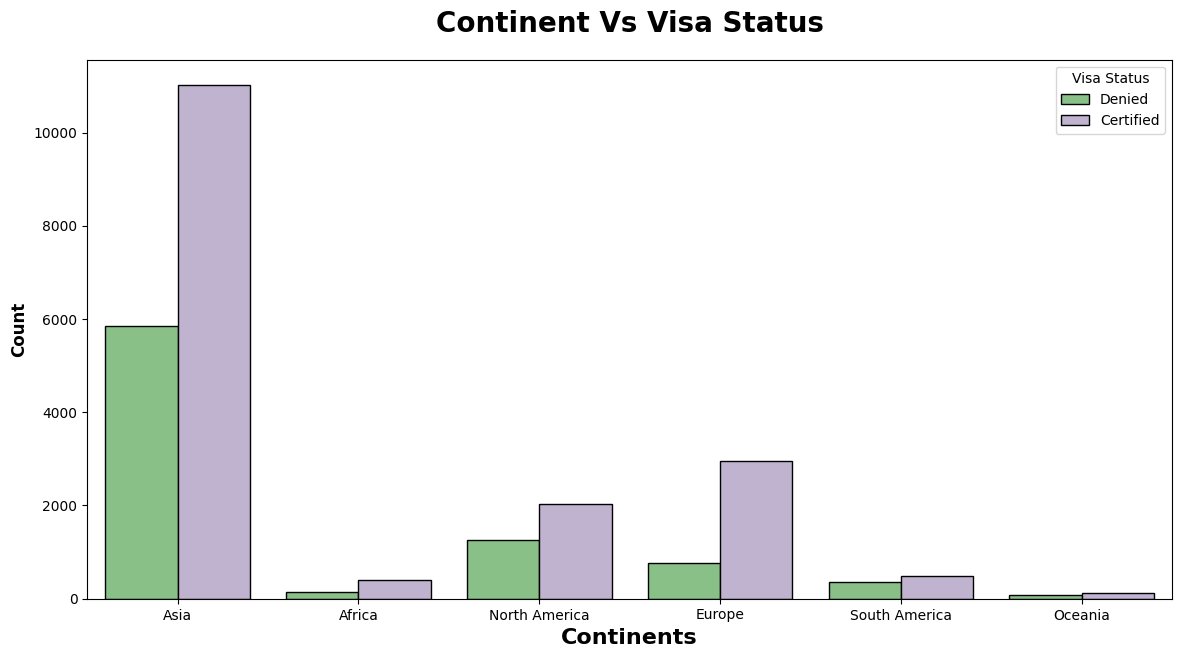

In [29]:
plt.subplots(figsize=(14,7))
sns.countplot(x ='continent', hue= 'case_status', data=df, ec='black', palette='Accent')
plt.title('Continent Vs Visa Status', weight = 'bold', fontsize=20, pad=20)
plt.ylabel('Count', weight= 'bold', fontsize= 12)
plt.xlabel('Continents', weight= 'bold', fontsize =16)
plt.legend(title= "Visa Status", fancybox = True)

In [30]:
df2= df.copy()

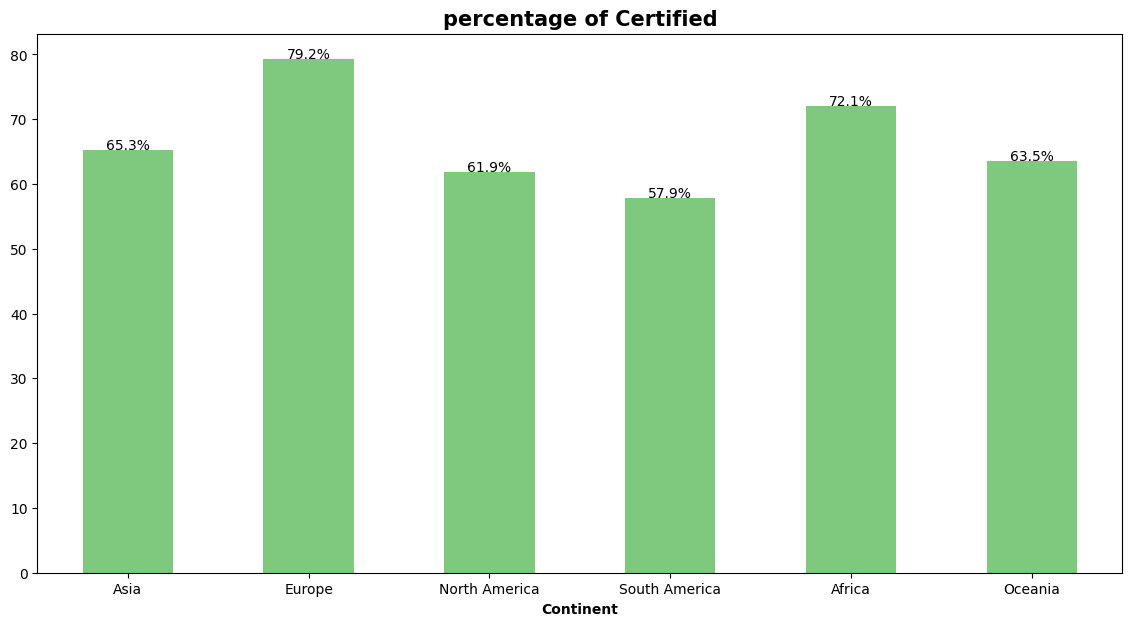

In [31]:

# certified visual :
plt.figure(figsize=(14,7))

(100*df2[df2['case_status'].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts()).plot(kind= 'bar',stacked = True, colormap='Accent')

plt.title('percentage of Certified',fontsize =15, fontweight = 'bold')

order1=(100*df2[df2['case_status'].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts())

for n in range(order1.shape[0]):
    count =order1[n]
    strt ='{:0.1f}%'.format(count)
    plt.text(n,count+0.1, strt,ha='center')

plt.xlabel('Continent', fontweight='bold')
plt.xticks(rotation = 0)
plt.show()

both same | with comment

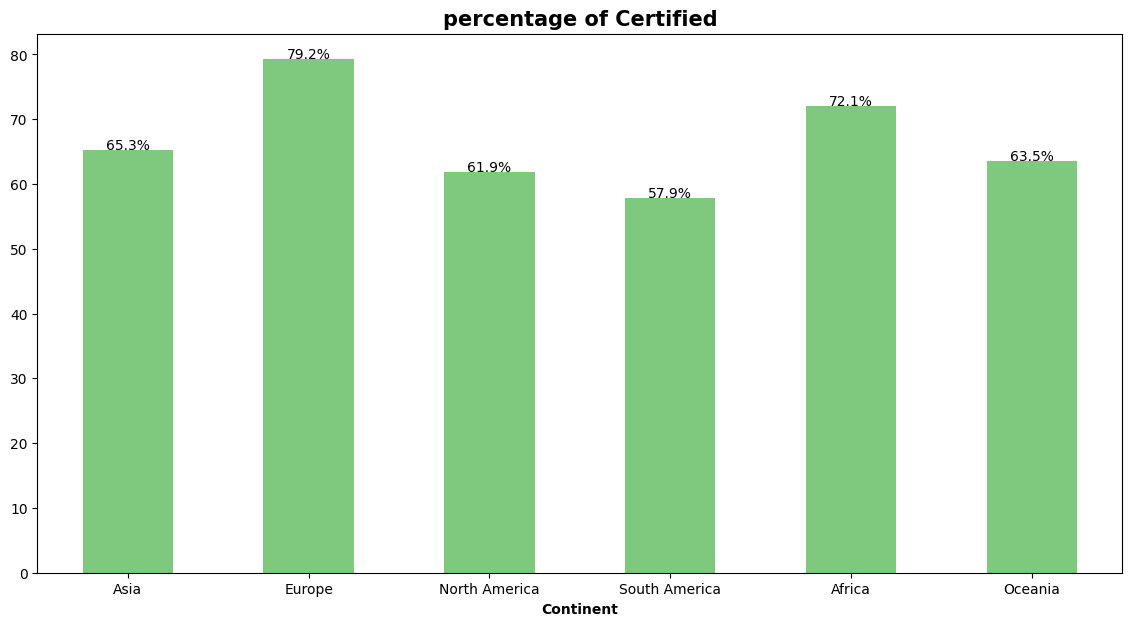

In [32]:
# Set the overall canvas dimensions to 14 inches wide by 7 inches high
plt.figure(figsize=(14, 7))

# Calculate the percentage of 'Certified' cases per continent:
# (Count of Certified cases by continent / Total count of cases by continent) * 100
# Then plot the result as a vertical bar chart using the 'Accent' color palette
(100 * df2[df2['case_status'].isin(['Certified'])]['continent'].value_counts() / df2['continent'].value_counts()).plot(
    kind='bar', 
    stacked=True, 
    colormap='Accent'
)

# Set the chart title with bold formatting and size 15 font
plt.title('percentage of Certified', fontsize=15, fontweight='bold')

# Store the calculated percentage series in 'order1' to use for bar label annotations
order1 = (100 * df2[df2['case_status'].isin(['Certified'])]['continent'].value_counts() / df2['continent'].value_counts())

# Loop through each bar in the plot to attach a percentage text label above it
for n in range(order1.shape[0]):
    count = order1[n]                          # Extract percentage value for continent at index n
    strt = '{:0.1f}%'.format(count)            # Format percentage to 1 decimal place (e.g., '85.4%')
    plt.text(n, count + 0.1, strt, ha='center')# Position text at bar index (x=n) slightly above bar height (y=count+0.1)

# Set X-axis label with bold font
plt.xlabel('Continent', fontweight='bold')

# Keep X-axis tick labels horizontal (0 degrees rotation) instead of tilted
plt.xticks(rotation=0)

# Render and display the final chart
plt.show()

**Report:**
* As per the Chart Asia applicants applied more than other continents.
* 43% of Certified applications are from Asia.
* This is followed by Europe with 11% of Certified applications.
* Highest chance of getting certified if you are from `Europe` and followed by `Africa`

### Does applicant Eduction has any impact on Visa Status?


In [33]:
df.head(2)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified


In [34]:
# Group data Education and their count of case_status | proportion
df.groupby('education_of_employee')['case_status'].value_counts(normalize = True).to_frame() *100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

In [35]:
import matplotlib.pyplot as plt

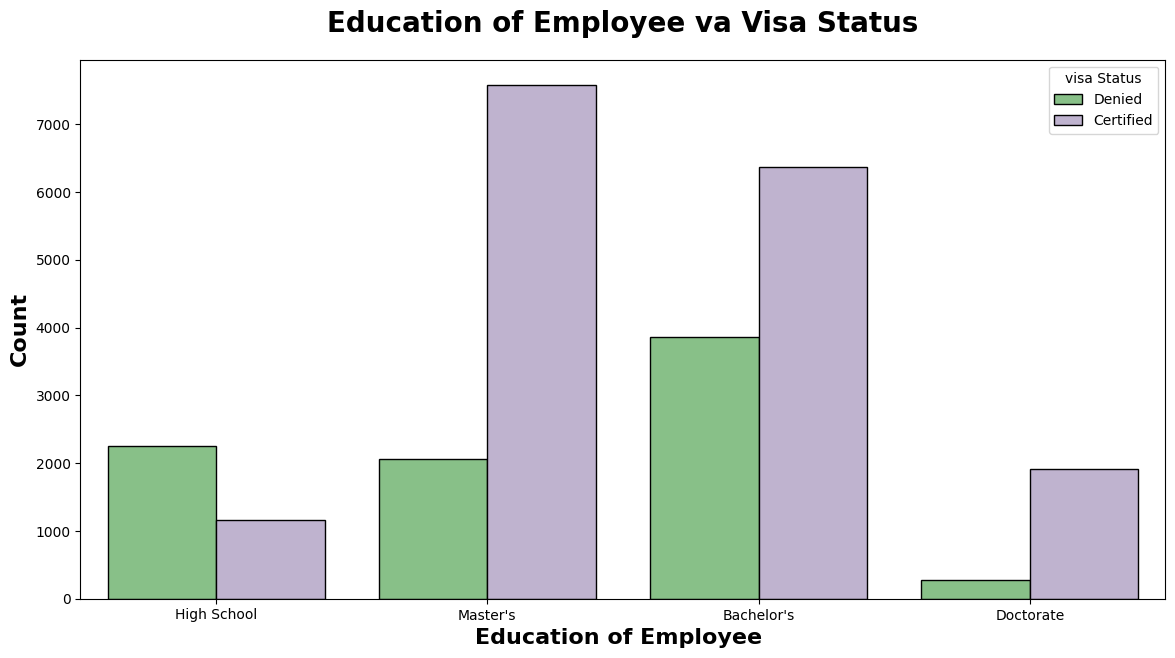

In [38]:
plt.subplots(figsize=(14, 7))
sns.countplot(data=df, x = 'education_of_employee', hue='case_status', ec= 'black', palette='Accent')
plt.title('Education of Employee va Visa Status', weight= 'bold', fontsize=20, pad=20)
plt.ylabel('Count', weight = 'bold', fontsize = 16)
plt.xlabel('Education of Employee ', weight= 'bold', fontsize = 16)
plt.legend(title='visa Status')
plt.show()

visual percenage of only Denied

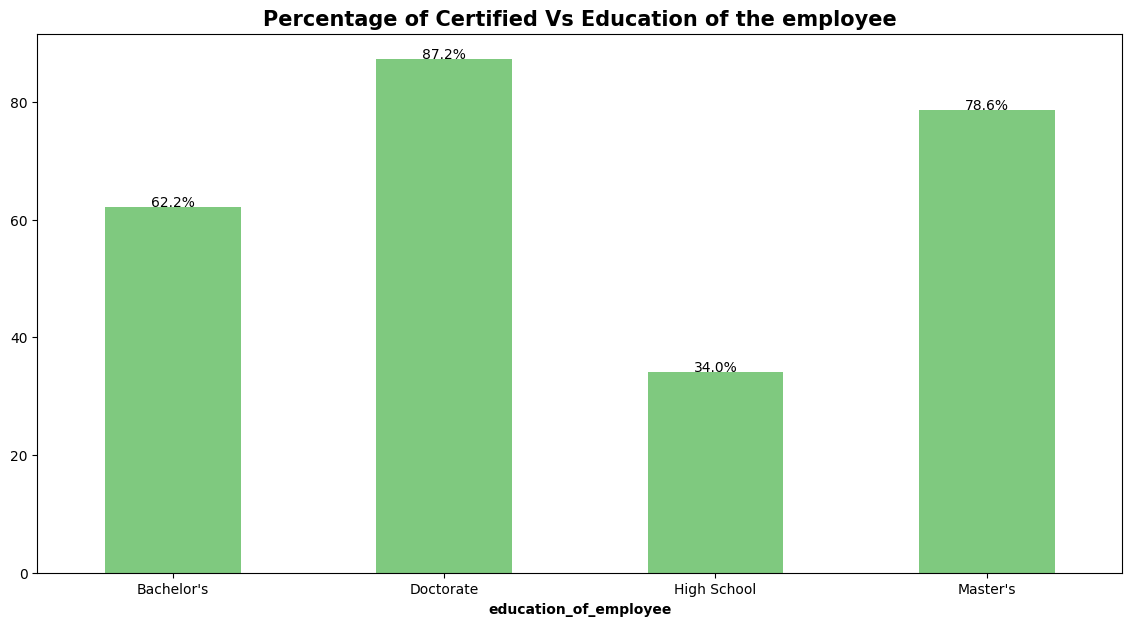

In [47]:
plt.figure(figsize=[14,7])

(100 * df2[df['case_status'].isin(['Certified'])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts()).plot(
    kind='bar', stacked=True, colormap='Accent')

plt.title('Percentage of Certified Vs Education of the employee', fontsize=15, fontweight='bold')
order1 =(100* df2[df['case_status'].isin(["Certified"])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts())

for n in range(order1.shape[0]):
    count = order1[n]
    strt ='{:0.1f}%'.format(count)
    plt.text(n,count+0.1, strt, ha= 'center')


plt.xlabel('education_of_employee' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()


### Insights 

- Education status has high impact.
- `Doctorate `and`Master's`graduates have higher chance of being accepted then the others.

### Does applicat's previous work experience has any impact on Visa Status?


In [49]:
# Group data by has_job experience and count casee_status

df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame() *100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

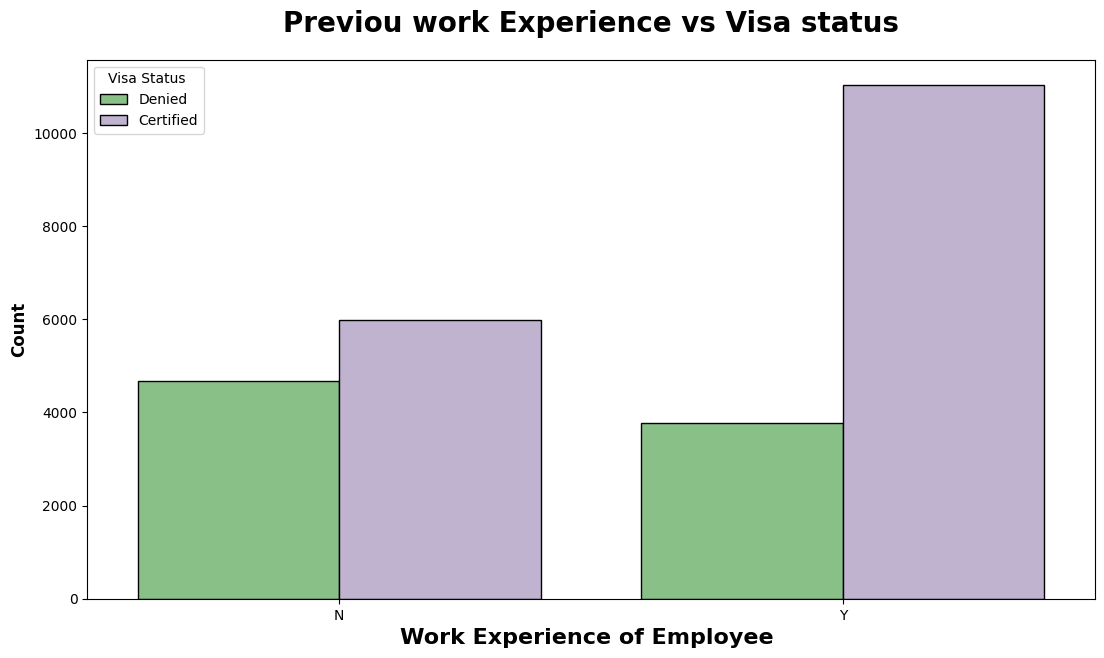

In [58]:
plt.subplots(figsize =(13,7))
sns.countplot(data=df, x= 'has_job_experience', hue='case_status', ec='black', palette='Accent')
plt.title('Previou work Experience vs Visa status', weight= 'bold', fontsize=20, pad=20)

plt.ylabel("Count", weight= 'bold', fontsize= 12)
plt.xlabel("Work Experience of Employee ", weight= 'bold', fontsize=16)

plt.legend(title='Visa Status ', fancybox= True)

plt.show()


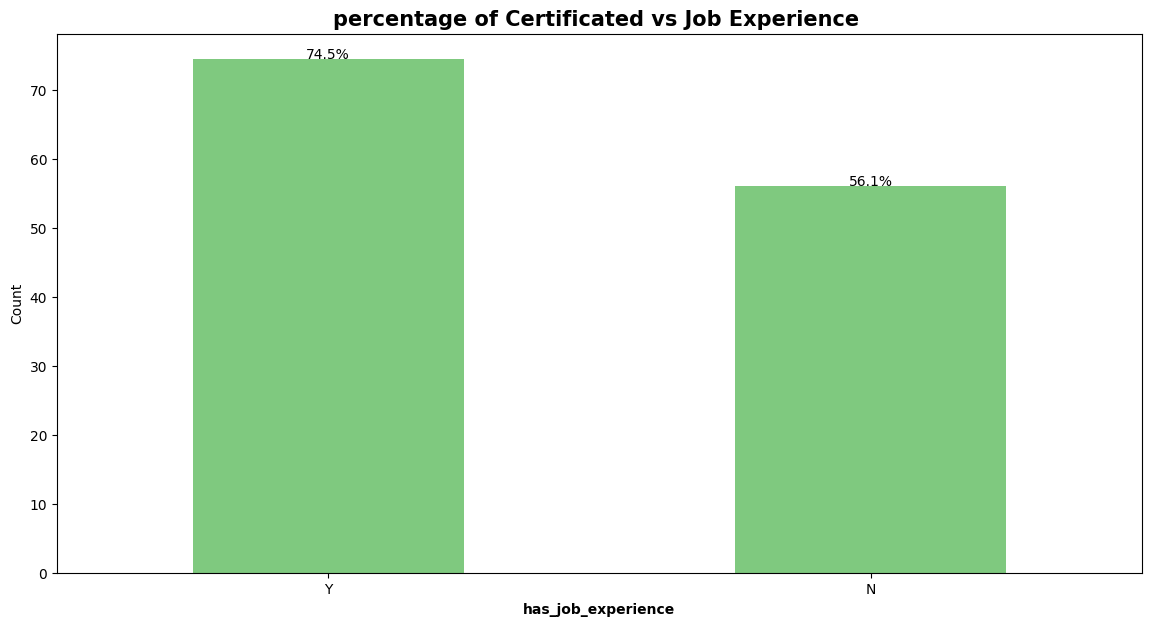

In [69]:
plt.figure(figsize=[14,7])

(100 * df2[df2['case_status'].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts()).plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)
plt.title('percentage of Certificated vs Job Experience ', fontsize =15, fontweight= 'bold')

order1 = (100 * df2[df2['case_status'].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts())

for n in range(order1.shape[0]):
    count = order1[n]                          # Extract percentage value for continent at index n
    strt = '{:0.1f}%'.format(count)            # Format percentage to 1 decimal place (e.g., '85.4%')
    plt.text(n, count + 0.1, strt, ha='center')# Position text at bar index (x=n) slightly above bar height (y=count+0.1)

# Set X-axis label with bold font
plt.xlabel('has_job_experience', fontweight='bold')
plt.ylabel('Count')

# Keep X-axis tick labels horizontal (0 degrees rotation) instead of tilted
plt.xticks(rotation=0)

# Render and display the final chart
plt.show()


## Denied percentage

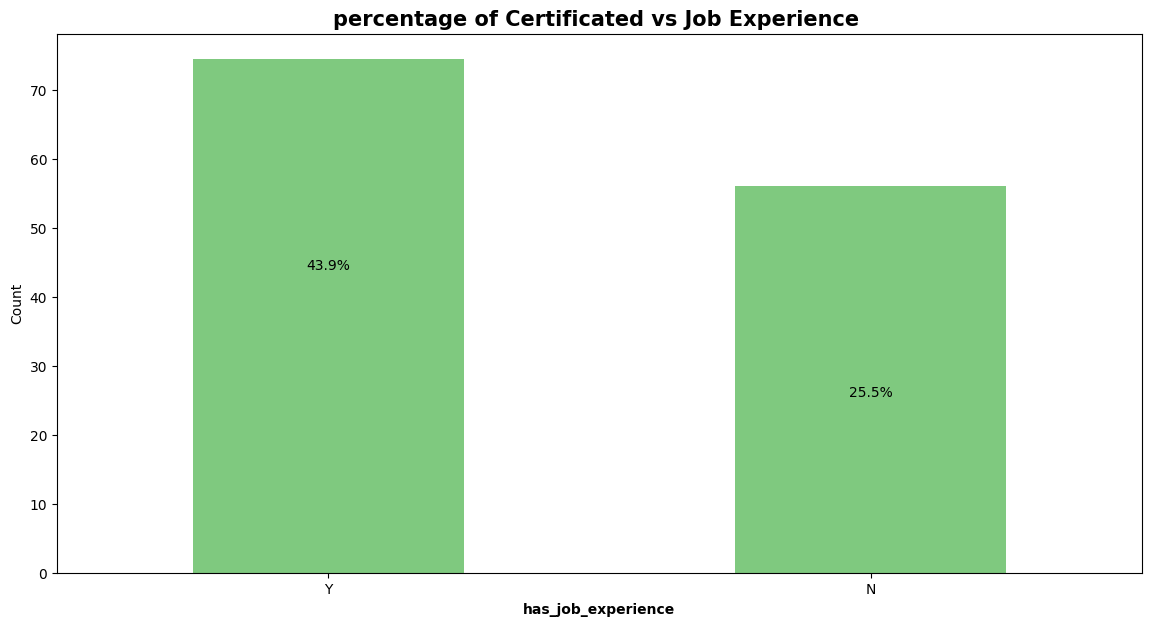

In [70]:
plt.figure(figsize=[14,7])

(100 * df2[df2['case_status'].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts()).plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)
plt.title('percentage of Certificated vs Job Experience ', fontsize =15, fontweight= 'bold')

order1 = (100 * df2[df2['case_status'].isin(['Denied'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts())

for n in range(order1.shape[0]):
    count = order1[n]                          # Extract percentage value for continent at index n
    strt = '{:0.1f}%'.format(count)            # Format percentage to 1 decimal place (e.g., '85.4%')
    plt.text(n, count + 0.1, strt, ha='center')# Position text at bar index (x=n) slightly above bar height (y=count+0.1)

# Set X-axis label with bold font
plt.xlabel('has_job_experience', fontweight='bold')
plt.ylabel('Count')

# Keep X-axis tick labels horizontal (0 degrees rotation) instead of tilted
plt.xticks(rotation=0)

# Render and display the final chart
plt.show()

## If the Employee requires job training does it make any impact on visa status?

In [71]:
# Groupby data requires_job_trainig and count case_status

df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame() *100


proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

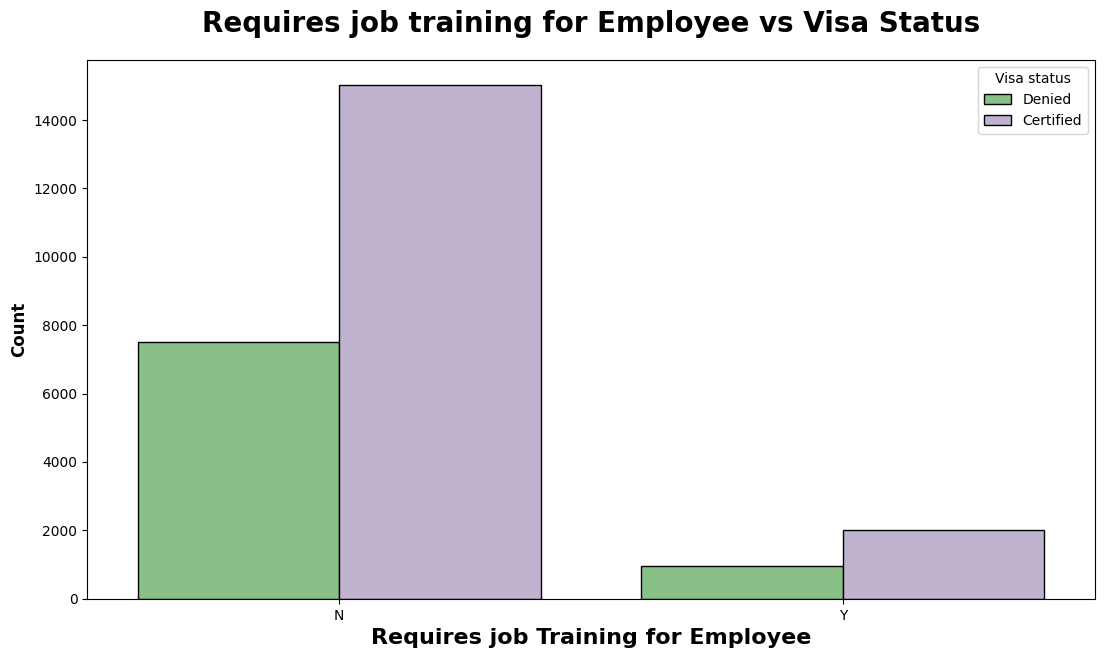

In [75]:
plt.subplots(figsize=(13,7))

sns.countplot(data=df, x='requires_job_training', hue='case_status', ec='black', palette='Accent')

plt.title("Requires job training for Employee vs Visa Status", weight= 'bold', fontsize = 20, pad=20)

plt.ylabel('Count', weight='bold', fontsize=12)
plt.xlabel("Requires job Training for Employee", weight = 'bold', fontsize =16)

plt.legend(title='Visa status', fancybox = True)

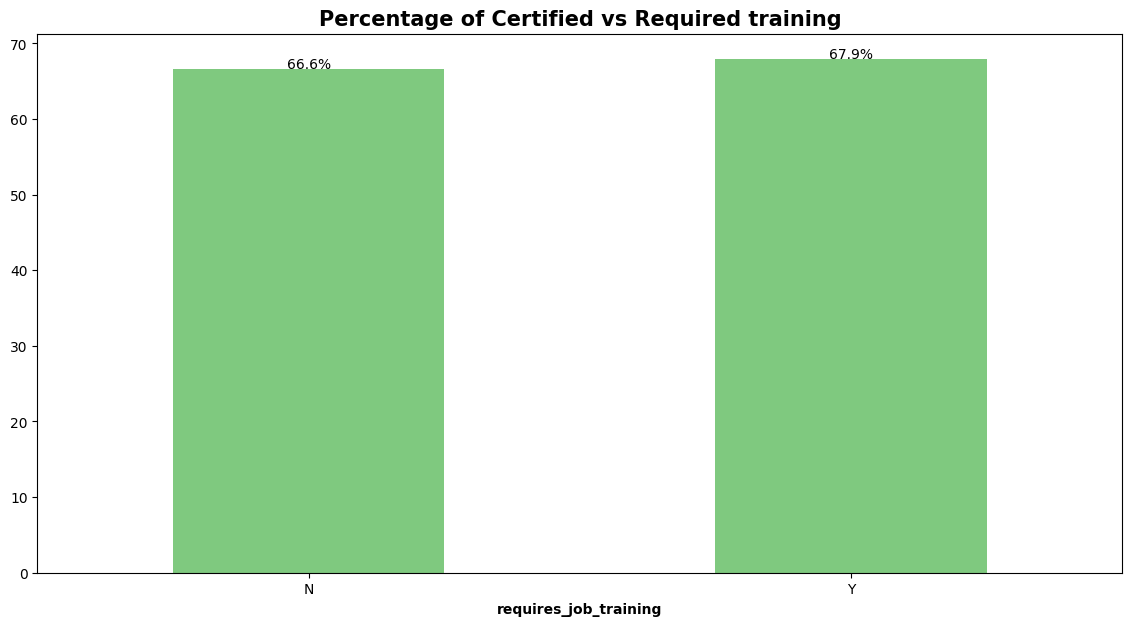

In [79]:
plt.figure(figsize=[14,7])

(100* df2[df2['case_status'].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts()).plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)

plt.title("Percentage of Certified vs Required training" , fontsize = 15, fontweight ='bold'  )

order1 =(100* df2[df2['case_status'].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts()
         )

for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1, strt, ha='center')

plt.xlabel('requires_job_training' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

### Wages and its impact on Visa Status

In [84]:
# Group data by unit unit_of_wage and count the case_stats

df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True) 

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

In [87]:
#group data by unit_of_wage and count the case_status
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True).to_frame() *100

proportion
unit_of_wage case_status            
Hour         Denied        65.368567
             Certified     34.631433
Month        Certified     61.797753
             Denied        38.202247
Week         Certified     62.132353
             Denied        37.867647
Year         Certified     69.885027
             Denied        30.114973

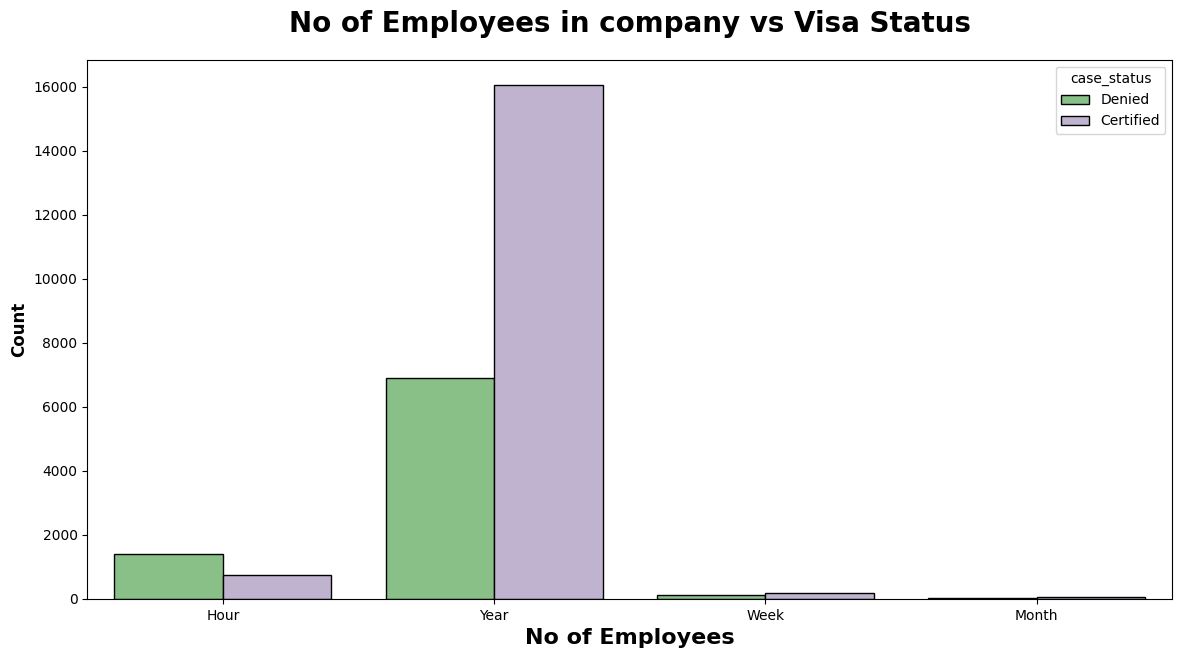

In [88]:
plt.subplots(figsize=(14,7))
sns.countplot(x="unit_of_wage",hue="case_status", data=df,ec='k', palette='Accent')
plt.title("No of Employees in company vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("No of Employees", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

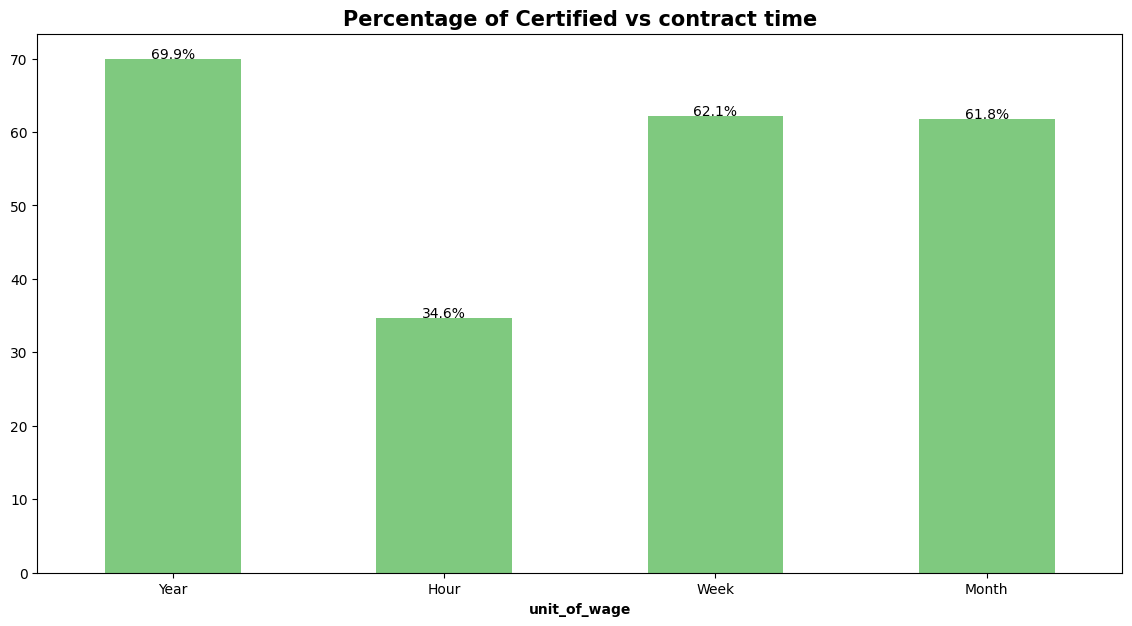

In [89]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['unit_of_wage'].value_counts()/df2['unit_of_wage'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs contract time" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['unit_of_wage'].value_counts()/df2['unit_of_wage'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('unit_of_wage' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

For FE : 
1. Missing value -NO
2. Categorical Handler - Yes
3. Outlier -Yes
4. Imbalance - Yes
5. Duplicates -No
6. Drop any column -Yes 
8. Scaling -Yes
9. Transformation -Yes

In [ ]:
#=======================================Next Feature Enginnering ===========================